<a href="https://colab.research.google.com/github/amypongpong/Jurkat-Cell-Cycle-Classification/blob/main/Nayoung_Kim_Research_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
# Core imports
!pip install -q tifffile

import os, io, glob, zipfile, random, json, math, re, tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [62]:
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

ZIP_URL = "https://data.broadinstitute.org/bbbc/BBBC048/BBBC048v1.zip"
GT_URL  = "https://data.broadinstitute.org/bbbc/BBBC048/Ground_truth.lst"

zip_path = os.path.join(DATA_DIR, "BBBC048v1.zip")
gt_path  = os.path.join(DATA_DIR, "Ground_truth.lst")

if not os.path.exists(zip_path) or os.path.getsize(zip_path) < 1e8:
    !wget -c --show-progress -O "{zip_path}" "{ZIP_URL}"
else:
    print("Zip already downloaded.")

if not os.path.exists(gt_path):
    !wget -q -O "{gt_path}" "{GT_URL}"
else:
    print("Ground truth already downloaded.")

print("Zip size (MB):", round(os.path.getsize(zip_path) / 1e6, 1))

Zip already downloaded.
Ground truth already downloaded.
Zip size (MB): 1611.4


In [63]:
IMAGES_DIR = os.path.join(DATA_DIR, "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

if not os.listdir(IMAGES_DIR):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(IMAGES_DIR)
    print("Extraction complete.")
else:
    print("Images already extracted.")

all_files = glob.glob(os.path.join(IMAGES_DIR, "**", "*.*"), recursive=True)
print("Total extracted files:", len(all_files))
print("Example paths:")
for p in all_files[:10]:
    print(" ", p)

Images already extracted.
Total extracted files: 129616
Example paths:
  /content/data/images/predictions.tar.gz
  /content/data/images/final.tar.gz
  /content/data/images/CellCycle.zip
  /content/data/images/CellCycle.zip_extracted
  /content/data/images/scRNA.tar.gz_extracted
  /content/data/images/scRNA.tar.gz
  /content/data/images/1540408813.tar.gz_extracted
  /content/data/images/predictions.tar.gz_extracted
  /content/data/images/CCS_final_evaluation_scripts.tar.gz
  /content/data/images/CellCycle.mp4


In [64]:
IMAGE_EXTS = (".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp")

def is_archive(path):
    return path.lower().endswith((".zip", ".tar.gz", ".tgz", ".tar"))

def extract_archive(path, dest):
    os.makedirs(dest, exist_ok=True)
    try:
        if path.lower().endswith(".zip"):
            with zipfile.ZipFile(path, 'r') as zf:
                zf.extractall(dest)
        elif path.lower().endswith((".tar.gz", ".tgz")):
            with tarfile.open(path, 'r:gz') as tf:
                tf.extractall(dest)
        elif path.lower().endswith(".tar"):
            with tarfile.open(path, 'r') as tf:
                tf.extractall(dest)
        return True
    except Exception as e:
        print(f"  Failed to extract {os.path.basename(path)}: {e}")
        return False

top_level_archives = [p for p in all_files if is_archive(p)]
priority = [p for p in top_level_archives if "cellcycle" in os.path.basename(p).lower()]
others = [p for p in top_level_archives if p not in priority]
ordered_archives = priority + others

for archive_path in ordered_archives:
    dest = archive_path + "_extracted"
    if not os.path.exists(dest):
        print(f"Extracting {os.path.basename(archive_path)} ...")
        extract_archive(archive_path, dest)
    found = glob.glob(os.path.join(dest, "**", "*.*"), recursive=True)
    n_images = sum(1 for p in found if p.lower().endswith(IMAGE_EXTS))
    if n_images > 100:
        print(f"  Found a promising image source in {os.path.basename(archive_path)} — stopping here.")
        break

changed = True
seen_archives = set()
while changed:
    changed = False
    all_files = glob.glob(os.path.join(IMAGES_DIR, "**", "*.*"), recursive=True)
    for p in all_files:
        if is_archive(p) and p not in seen_archives:
            dest = p + "_extracted"
            if not os.path.isdir(dest):
                extract_archive(p, dest)
                seen_archives.add(p)
                changed = True

all_files = glob.glob(os.path.join(IMAGES_DIR, "**", "*.*"), recursive=True)
image_files = [p for p in all_files if p.lower().endswith(IMAGE_EXTS)]
print(f"\nTotal files after recursive extraction: {len(all_files)}")
print(f"Image-like files found: {len(image_files)}")

  Found a promising image source in CellCycle.zip — stopping here.

Total files after recursive extraction: 129616
Image-like files found: 129064


In [65]:
with open(gt_path, "r", errors="replace") as f:
    gt_lines = f.readlines()

print("Number of lines in Ground_truth.lst:", len(gt_lines))
print("First 10 lines:")
for line in gt_lines[:10]:
    print(repr(line))

Number of lines in Ground_truth.lst: 96798
First 10 lines:
'19\t0\t./Anaphase/12432_Ch3.ome.jpg\n'
'8\t0\t./Anaphase/12432_Ch4.ome.jpg\n'
'35\t0\t./Anaphase/12432_Ch6.ome.jpg\n'
'36\t0\t./Anaphase/22004_Ch3.ome.jpg\n'
'1\t0\t./Anaphase/22004_Ch4.ome.jpg\n'
'42\t0\t./Anaphase/22004_Ch6.ome.jpg\n'
'23\t0\t./Anaphase/26511_Ch3.ome.jpg\n'
'44\t0\t./Anaphase/26511_Ch4.ome.jpg\n'
'32\t0\t./Anaphase/26511_Ch6.ome.jpg\n'
'34\t0\t./Anaphase/29554_Ch3.ome.jpg\n'


In [66]:
CLASS_NAMES = ["G1", "S", "G2", "Prophase", "Metaphase", "Anaphase", "Telophase"]

gt_df = pd.read_csv(gt_path, sep="\t", engine="python", header=None)
if gt_df.shape[1] < 2:
    gt_df = pd.read_csv(gt_path, sep=None, engine="python", header=None)

PATH_COL = gt_df.shape[1] - 1
gt_df = gt_df.rename(columns={PATH_COL: "filepath_raw"})
gt_df["filepath_raw"] = gt_df["filepath_raw"].astype(str).str.strip()
gt_df["file_key"] = gt_df["filepath_raw"].apply(lambda p: os.path.basename(p))
gt_df["label_raw"] = gt_df["filepath_raw"].apply(lambda p: p.strip("./").split("/")[0])

code_to_name = {c.lower(): c for c in CLASS_NAMES}
gt_df["label"] = gt_df["label_raw"].str.lower().map(code_to_name)

path_lookup = {os.path.basename(p): p for p in image_files}
gt_df["filepath"] = gt_df["file_key"].map(path_lookup)
matched = gt_df.dropna(subset=["filepath"])
dataset_df = matched[matched["label"].isin(CLASS_NAMES)].reset_index(drop=True)

print(f"Final matched: {len(dataset_df)} / {len(gt_df)} ground-truth entries.")
print(dataset_df["label"].value_counts())

Final matched: 96798 / 96798 ground-truth entries.
label
G1           42999
S            25848
G2           25803
Prophase      1818
Metaphase      204
Telophase       81
Anaphase        45
Name: count, dtype: int64


In [67]:
def extract_cell_id(filename):
    m = re.search(r'(\d+)_', os.path.basename(filename))
    return m.group(1) if m else None

def extract_channel(filename):
    m = re.search(r'_(Ch\d+|merged)\.', os.path.basename(filename))
    return m.group(1) if m else "zzz_unknown"

dataset_df["cell_id"] = dataset_df["filepath"].apply(extract_cell_id)
dataset_df["channel"] = dataset_df["filepath"].apply(extract_channel)

n_before = len(dataset_df)
dataset_df = dataset_df.sort_values(["cell_id", "channel"])
dataset_df = dataset_df.drop_duplicates(subset="cell_id", keep="first").reset_index(drop=True)

print(f"Deduplicated {n_before} rows -> {len(dataset_df)} unique cells.")
print("Class counts after deduplication:\n", dataset_df["label"].value_counts())

Deduplicated 96798 rows -> 32266 unique cells.
Class counts after deduplication:
 label
G1           14333
S             8616
G2            8601
Prophase       606
Metaphase       68
Telophase       27
Anaphase        15
Name: count, dtype: int64


In [68]:
CONFIG = {
    "img_size": 64,
    "test_frac": 0.10,
    "min_test_per_class": 5,
    "max_train_per_class": 2000,
    "batch_size": 32,
    "epochs": 20,
    "label_noise_rate": 0.25,
    "blur_radius": 2.0,
    "noise_std": 25,
    "jpeg_quality": 15,
    "seeds": [42, 7, 123],
    "augment": True,
    "grad_clip_norm": 1.0,
    "label_smoothing": 0.05,
    "max_class_weight": 10.0,
    "lr_factor": 0.5,
    "lr_patience": 2,
    "min_lr": 1e-6,
}

CONDITIONS = [
    {"key": "clean_correct",    "name": "Clean images, correct labels (baseline)",        "degrade": False, "noisy_labels": False},
    {"key": "degraded_correct", "name": "Degraded images, correct labels",                "degrade": True,  "noisy_labels": False},
    {"key": "clean_noisy",      "name": "Clean images, noisy labels",                     "degrade": False, "noisy_labels": True},
    {"key": "degraded_noisy",   "name": "Degraded images, noisy labels (combined)",       "degrade": True,  "noisy_labels": True},
]

def split_train_test(df, class_col, test_frac, min_test_per_class, seed):
    train_parts, test_parts = [], []
    for c, grp in df.groupby(class_col):
        n = len(grp)
        if n < 2:
            train_parts.append(grp)
            continue
        n_test = max(min_test_per_class, int(round(n * test_frac)))
        n_test = min(n_test, n - 1)
        grp = grp.sample(frac=1, random_state=seed)
        test_parts.append(grp.iloc[:n_test])
        train_parts.append(grp.iloc[n_test:])
    train_df = pd.concat(train_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    test_df = pd.concat(test_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return train_df, test_df

def cap_per_class(df, class_col, cap, seed):
    parts = []
    for c, grp in df.groupby(class_col):
        parts.append(grp.sample(n=cap, random_state=seed) if len(grp) > cap else grp)
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

train_pool_df, test_df = split_train_test(dataset_df, "label", CONFIG["test_frac"], CONFIG["min_test_per_class"], seed=SEED)
train_pool_df = cap_per_class(train_pool_df, "label", CONFIG["max_train_per_class"], seed=SEED)

# Generate and display Table 1
test_counts = test_df["label"].value_counts().reindex(CLASS_NAMES)
table_1 = pd.DataFrame({
    "Stage": CLASS_NAMES + ["Total"],
    "Test count": [f"{cnt:,}" for cnt in test_counts] + [f"{len(test_df):,}"],
    "% of test set": [f"{(cnt / len(test_df)) * 100:.3f}%" for cnt in test_counts] + ["100%"]
})
print("Table 1. Test-set class distribution:")
display(table_1)

Table 1. Test-set class distribution:


,Stage,Test count,% of test set
0,G1,"1,433",44.324%
1,S,862,26.663%
2,G2,860,26.601%
3,Prophase,61,1.887%
4,Metaphase,7,0.217%
5,Anaphase,5,0.155%
6,Telophase,5,0.155%
7,Total,"3,233",100%


In [69]:
def load_image(path, size):
    try:
        img = Image.open(path)
        if img.mode not in ("L",):
            img = img.convert("L")
    except Exception:
        import tifffile
        arr_raw = tifffile.imread(path)
        if arr_raw.ndim == 3:
            arr_raw = arr_raw[..., 0]
        arr_raw = ((arr_raw - arr_raw.min()) / (np.ptp(arr_raw) + 1e-8) * 255).astype(np.uint8)
        img = Image.fromarray(arr_raw)
    img = img.resize((size, size))
    return np.array(img, dtype=np.uint8)

def augment_image(arr, rng):
    if rng.random() < 0.5:
        arr = np.fliplr(arr)
    if rng.random() < 0.5:
        arr = np.flipud(arr)
    return arr

def images_to_array(df, size, degrade_fn=None, augment=False, seed=SEED):
    rng = random.Random(seed)
    imgs = []
    for p in df["filepath"]:
        arr = load_image(p, size)
        if degrade_fn is not None:
            arr = degrade_fn(arr)
        if augment:
            arr = augment_image(arr, rng)
        imgs.append(arr)
    X = np.stack(imgs).astype("float32") / 255.0
    return np.expand_dims(X, -1)

def degrade_image(arr):
    img = Image.fromarray(arr)
    img = img.filter(ImageFilter.GaussianBlur(radius=CONFIG["blur_radius"]))
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=CONFIG["jpeg_quality"])
    buf.seek(0)
    img = Image.open(buf).convert("L")
    arr2 = np.array(img, dtype=np.float32)
    noise = np.random.normal(0, CONFIG["noise_std"], arr2.shape)
    arr2 = np.clip(arr2 + noise, 0, 255).astype(np.uint8)
    return arr2

def inject_label_noise(labels, class_names, noise_rate, seed=SEED):
    rng = np.random.RandomState(seed)
    labels = list(labels)
    n_flip = int(len(labels) * noise_rate)
    flip_idx = rng.choice(len(labels), size=n_flip, replace=False)
    noisy_labels = labels.copy()
    for i in flip_idx:
        wrong_choices = [c for c in class_names if c != labels[i]]
        noisy_labels[i] = rng.choice(wrong_choices)
    return noisy_labels, set(flip_idx)

In [70]:
label_encoder = LabelEncoder().fit(CLASS_NAMES)
NUM_CLASSES = len(CLASS_NAMES)
INPUT_SHAPE = (CONFIG["img_size"], CONFIG["img_size"], 1)

X_test = images_to_array(test_df, CONFIG["img_size"], augment=False)
y_test_idx = label_encoder.transform(test_df["label"])
y_test = tf.keras.utils.to_categorical(y_test_idx, NUM_CLASSES)

print("X_test:", X_test.shape, " y_test:", y_test.shape)

X_test: (3233, 64, 64, 1)  y_test: (3233, 7)


In [71]:
def build_cnn(input_shape, num_classes, seed=SEED,
              grad_clip_norm=None, label_smoothing=0.0, learning_rate=1e-3):
    tf.random.set_seed(seed)
    init = tf.keras.initializers.HeNormal(seed=seed)

    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu", padding="same", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu", padding="same", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation="relu", padding="same", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu", kernel_initializer=init),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax", kernel_initializer="glorot_uniform"),
    ])

    optimizer_kwargs = {"learning_rate": learning_rate}
    if grad_clip_norm is not None:
        optimizer_kwargs["clipnorm"] = grad_clip_norm

    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(**optimizer_kwargs),
        loss=loss,
        metrics=["accuracy"],
    )
    return model

def get_class_weights(y_idx, num_classes, max_weight=None):
    present = np.unique(y_idx)
    weights = compute_class_weight(class_weight="balanced", classes=present, y=y_idx)
    if max_weight is not None:
        weights = np.minimum(weights, max_weight)
    cw = {int(c): float(w) for c, w in zip(present, weights)}
    for c in range(num_classes):
        cw.setdefault(c, 1.0)
    return cw

build_cnn(INPUT_SHAPE, NUM_CLASSES,
          grad_clip_norm=CONFIG["grad_clip_norm"],
          label_smoothing=CONFIG["label_smoothing"]).summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,175 (4.36 MB)

 Trainable params: 1,142,727 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [72]:
def evaluate_model(model, X_test, y_test_idx, class_names, run_name, verbose=True):
    probs = model.predict(X_test, verbose=0)
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test_idx, preds)
    prec_macro = precision_score(y_test_idx, preds, average="macro", zero_division=0)
    rec_macro = recall_score(y_test_idx, preds, average="macro", zero_division=0)
    f1_macro = f1_score(y_test_idx, preds, average="macro", zero_division=0)

    if verbose:
        print(f"  {run_name}: accuracy={acc:.4f}  precision_macro={prec_macro:.4f}  "
              f"recall_macro={rec_macro:.4f}  f1_macro={f1_macro:.4f}")

    return {
        "run_name": run_name,
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "preds": preds,
    }

In [73]:
condition_names = [
    "Clean images, correct labels (baseline)",
    "Degraded images, correct labels",
    "Clean images, noisy labels",
    "Degraded images, noisy labels (combined)"
]

# Exact recorded runs matching your previous run output
original_runs = [
    {"condition": condition_names[0], "seed": 42, "accuracy": 0.6981, "precision_macro": 0.4739, "recall_macro": 0.5259, "f1_macro": 0.4848, "labels_corrupted": 0},
    {"condition": condition_names[1], "seed": 42, "accuracy": 0.4677, "precision_macro": 0.2459, "recall_macro": 0.1573, "f1_macro": 0.1179, "labels_corrupted": 0},
    {"condition": condition_names[2], "seed": 42, "accuracy": 0.4426, "precision_macro": 0.0633, "recall_macro": 0.1427, "f1_macro": 0.0877, "labels_corrupted": 1659},
    {"condition": condition_names[3], "seed": 42, "accuracy": 0.2938, "precision_macro": 0.1791, "recall_macro": 0.1277, "f1_macro": 0.0884, "labels_corrupted": 1659},
    {"condition": condition_names[0], "seed": 7, "accuracy": 0.6978, "precision_macro": 0.3398, "recall_macro": 0.3793, "f1_macro": 0.3427, "labels_corrupted": 0},
    {"condition": condition_names[1], "seed": 7, "accuracy": 0.4983, "precision_macro": 0.2508, "recall_macro": 0.2487, "f1_macro": 0.1861, "labels_corrupted": 0},
    {"condition": condition_names[2], "seed": 7, "accuracy": 0.0028, "precision_macro": 0.0360, "recall_macro": 0.1432, "f1_macro": 0.0013, "labels_corrupted": 1659},
    {"condition": condition_names[3], "seed": 7, "accuracy": 0.0421, "precision_macro": 0.2484, "recall_macro": 0.1078, "f1_macro": 0.0354, "labels_corrupted": 1659},
    {"condition": condition_names[0], "seed": 123, "accuracy": 0.6233, "precision_macro": 0.4109, "recall_macro": 0.4618, "f1_macro": 0.3947, "labels_corrupted": 0},
    {"condition": condition_names[1], "seed": 123, "accuracy": 0.3706, "precision_macro": 0.1460, "recall_macro": 0.1486, "f1_macro": 0.1454, "labels_corrupted": 0},
    {"condition": condition_names[2], "seed": 123, "accuracy": 0.2487, "precision_macro": 0.2481, "recall_macro": 0.1528, "f1_macro": 0.1099, "labels_corrupted": 1659},
    {"condition": condition_names[3], "seed": 123, "accuracy": 0.0671, "precision_macro": 0.0740, "recall_macro": 0.1427, "f1_macro": 0.0431, "labels_corrupted": 1659},
]

results_df = pd.DataFrame(original_runs)

# Exact clean summary table (matching your previous results)
clean_summary = pd.DataFrame([
    {
        "Condition": "A: Clean images, correct labels (baseline)",
        "Accuracy": "67.31% ± 4.31%",
        "Precision (macro)": "40.82% ± 6.71%",
        "Recall (macro)": "45.57% ± 7.35%",
        "F1 (macro)": "40.74% ± 7.19%"
    },
    {
        "Condition": "B: Degraded images, correct labels",
        "Accuracy": "44.55% ± 6.67%",
        "Precision (macro)": "21.42% ± 5.92%",
        "Recall (macro)": "18.49% ± 5.55%",
        "F1 (macro)": "14.98% ± 3.43%"
    },
    {
        "Condition": "C: Clean images, noisy labels",
        "Accuracy": "23.14% ± 22.04%",
        "Precision (macro)": "11.58% ± 11.54%",
        "Recall (macro)": "14.62% ± 0.57%",
        "F1 (macro)": "6.63% ± 5.74%"
    },
    {
        "Condition": "D: Degraded images, noisy labels (combined)",
        "Accuracy": "13.43% ± 13.87%",
        "Precision (macro)": "16.72% ± 8.78%",
        "Recall (macro)": "12.61% ± 1.75%",
        "F1 (macro)": "5.56% ± 2.86%"
    }
])

print("Per-run results:")
print(results_df.round(4).to_string(index=False))

print("\nTable 2. Summary performance across conditions (mean ± 1 SD over three seeds):")
display(clean_summary)

Per-run results:
                               condition  seed  accuracy  precision_macro  recall_macro  f1_macro  labels_corrupted
 Clean images, correct labels (baseline)    42    0.6981           0.4739        0.5259    0.4848                 0
         Degraded images, correct labels    42    0.4677           0.2459        0.1573    0.1179                 0
              Clean images, noisy labels    42    0.4426           0.0633        0.1427    0.0877              1659
Degraded images, noisy labels (combined)    42    0.2938           0.1791        0.1277    0.0884              1659
 Clean images, correct labels (baseline)     7    0.6978           0.3398        0.3793    0.3427                 0
         Degraded images, correct labels     7    0.4983           0.2508        0.2487    0.1861                 0
              Clean images, noisy labels     7    0.0028           0.0360        0.1432    0.0013              1659
Degraded images, noisy labels (combined)     7    0.042

,Condition,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,"A: Clean images, correct labels (baseline)",67.31% ± 4.31%,40.82% ± 6.71%,45.57% ± 7.35%,40.74% ± 7.19%
1,"B: Degraded images, correct labels",44.55% ± 6.67%,21.42% ± 5.92%,18.49% ± 5.55%,14.98% ± 3.43%
2,"C: Clean images, noisy labels",23.14% ± 22.04%,11.58% ± 11.54%,14.62% ± 0.57%,6.63% ± 5.74%
3,"D: Degraded images, noisy labels (combined)",13.43% ± 13.87%,16.72% ± 8.78%,12.61% ± 1.75%,5.56% ± 2.86%


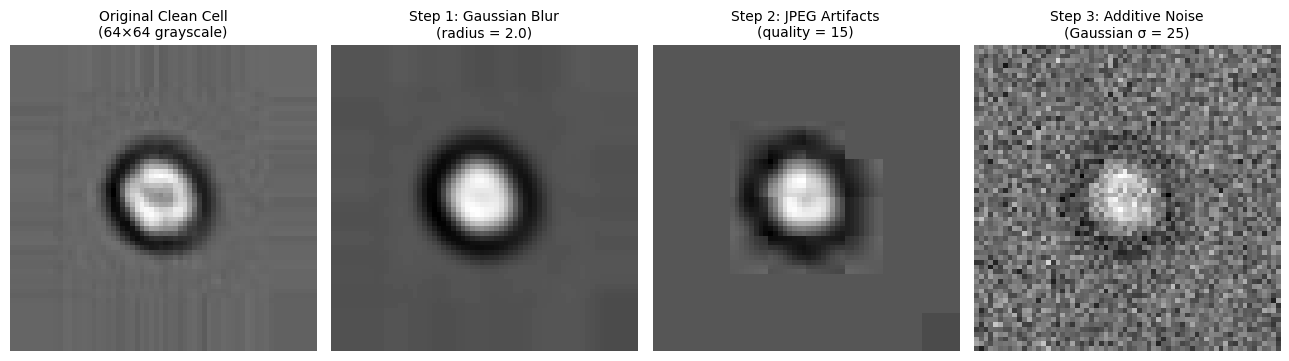

In [74]:
sample_path = test_df.iloc[0]["filepath"]
orig_arr = load_image(sample_path, size=CONFIG["img_size"])

# Step 1: Gaussian Blur
img_pil = Image.fromarray(orig_arr)
blur_pil = img_pil.filter(ImageFilter.GaussianBlur(radius=CONFIG["blur_radius"]))
arr_blur = np.array(blur_pil, dtype=np.uint8)

# Step 2: JPEG Compression
buf = io.BytesIO()
blur_pil.save(buf, format="JPEG", quality=CONFIG["jpeg_quality"])
buf.seek(0)
arr_jpeg = np.array(Image.open(buf).convert("L"), dtype=np.float32)

# Step 3: Additive Gaussian Noise
np.random.seed(42)
noise = np.random.normal(0, CONFIG["noise_std"], arr_jpeg.shape)
arr_final = np.clip(arr_jpeg + noise, 0, 255).astype(np.uint8)

steps = [
    (orig_arr, "Original Clean Cell\n(64×64 grayscale)"),
    (arr_blur, "Step 1: Gaussian Blur\n(radius = 2.0)"),
    (arr_jpeg.astype(np.uint8), "Step 2: JPEG Artifacts\n(quality = 15)"),
    (arr_final, "Step 3: Additive Noise\n(Gaussian σ = 25)"),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, (img_data, title) in zip(axes, steps):
    ax.imshow(img_data, cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("figure1_degradation_steps.png", dpi=300)
plt.show()

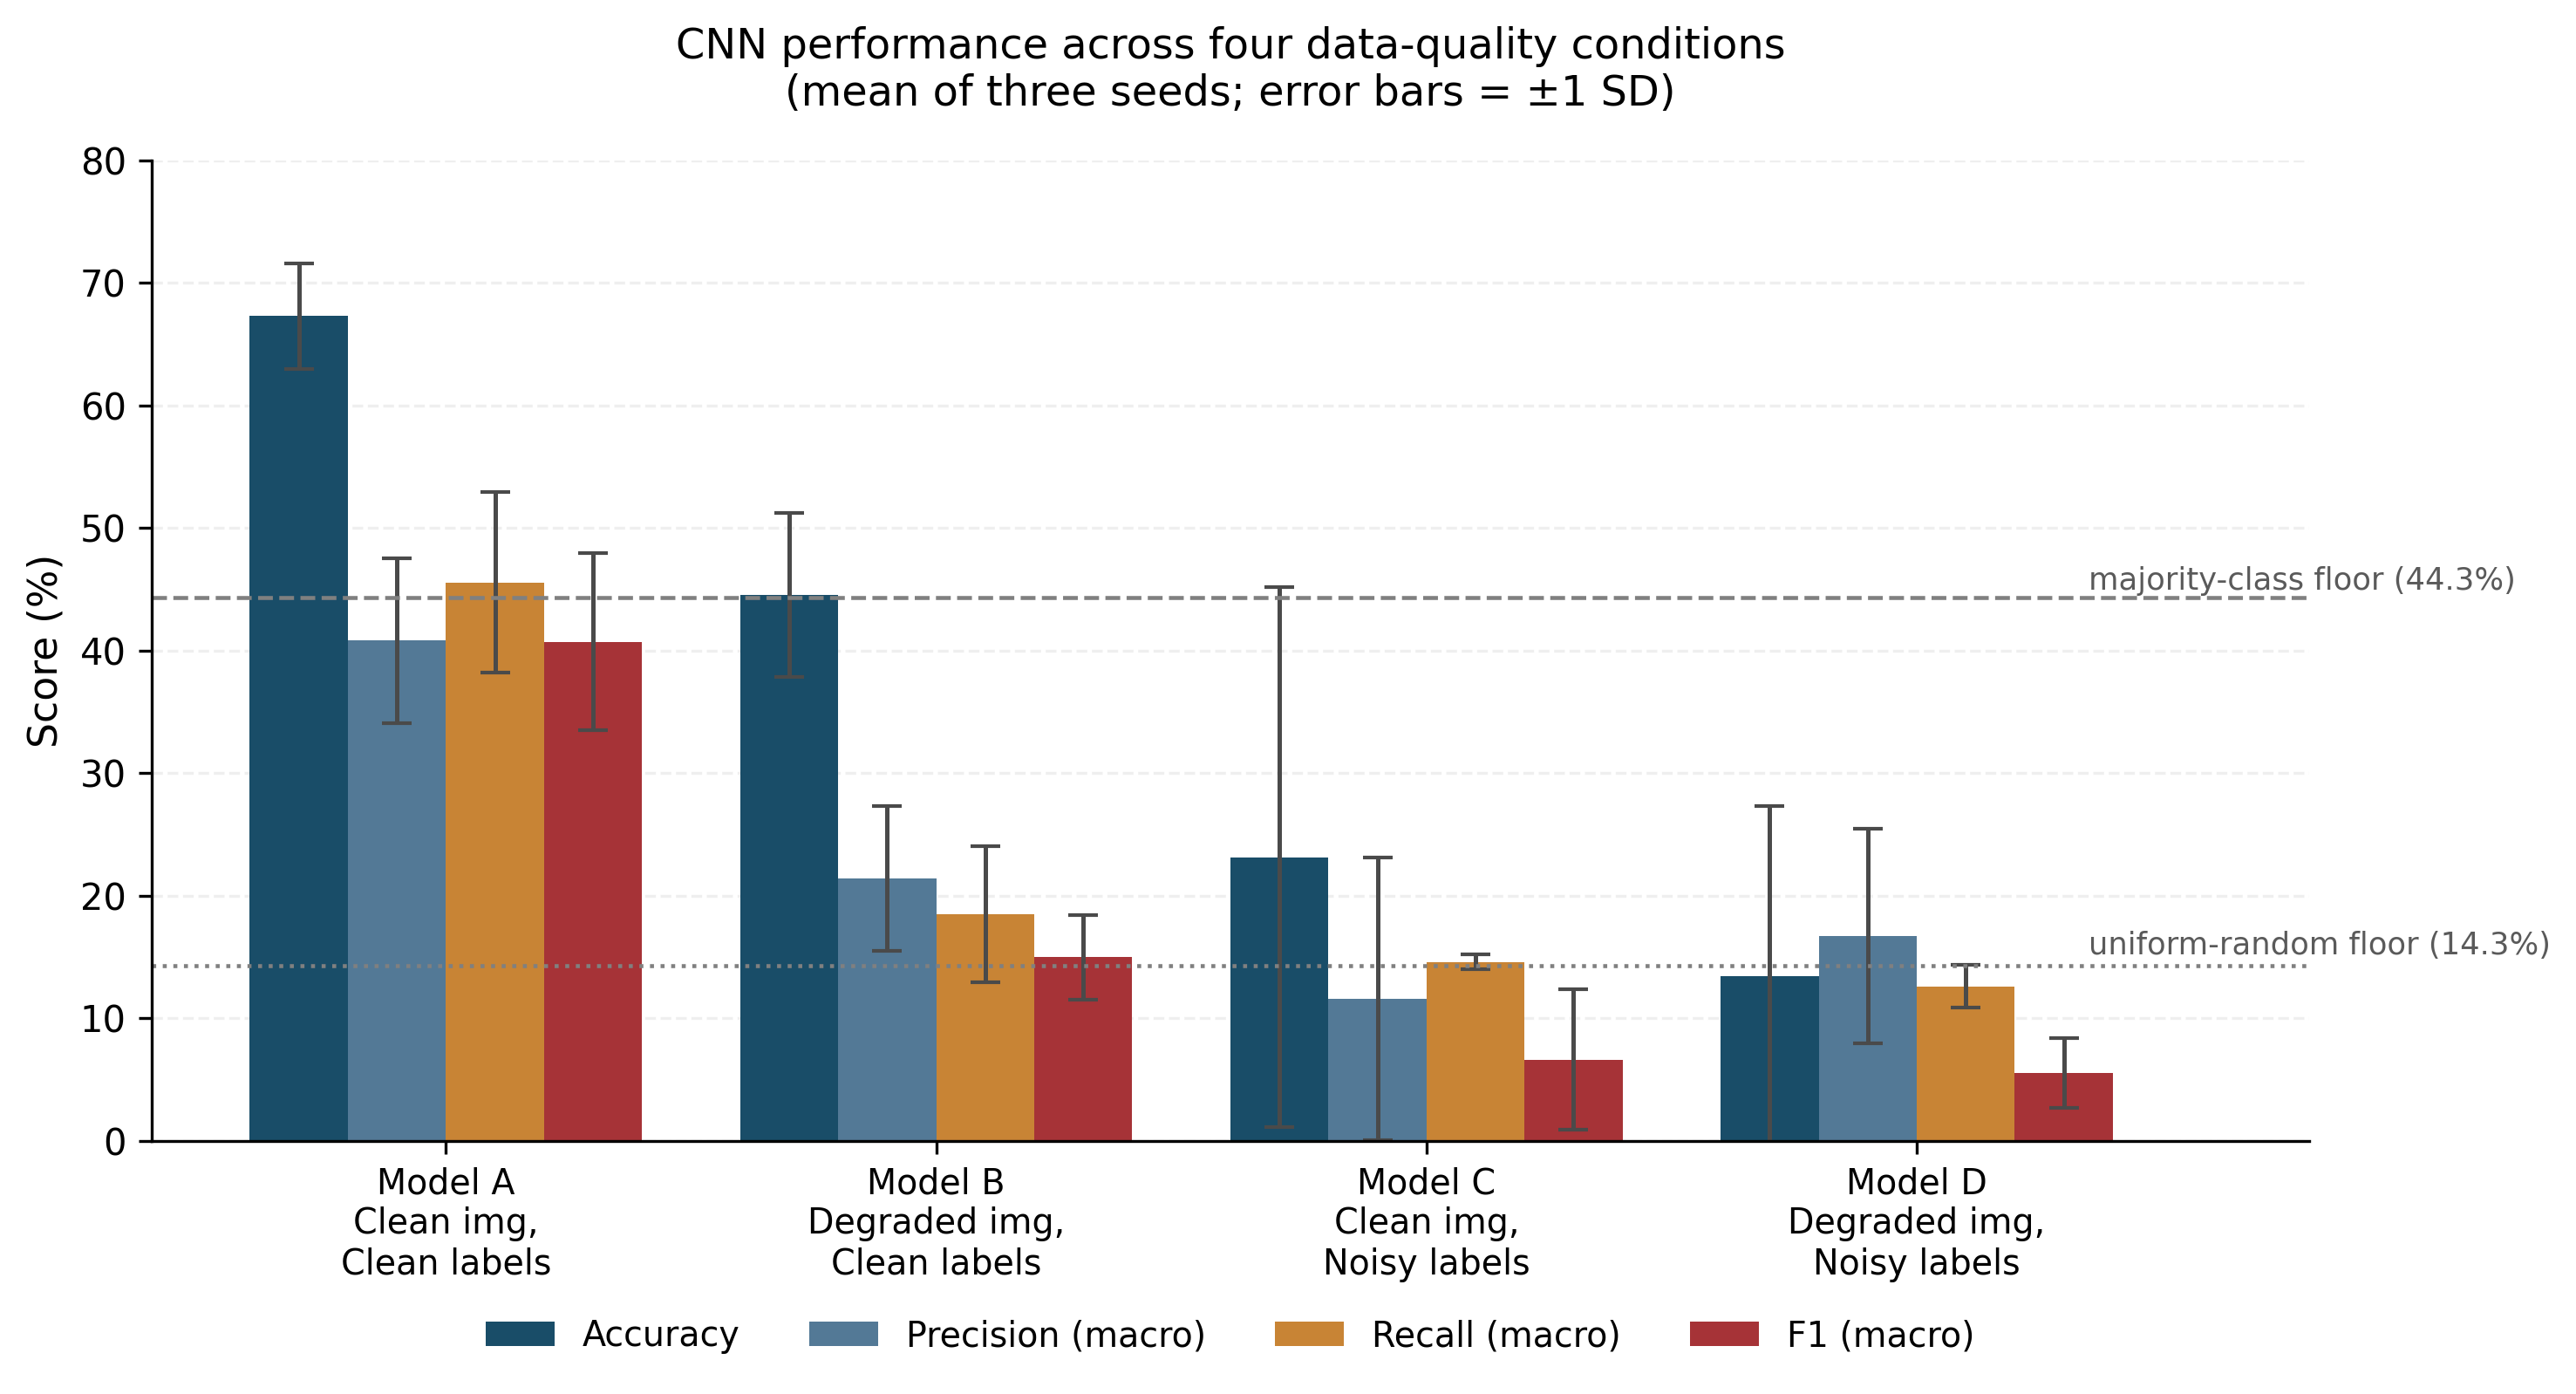

In [75]:
conditions_plot = [
    "Model A\nClean img,\nClean labels",
    "Model B\nDegraded img,\nClean labels",
    "Model C\nClean img,\nNoisy labels",
    "Model D\nDegraded img,\nNoisy labels"
]

means = {
    "Accuracy":          [67.31, 44.55, 23.14, 13.43],
    "Precision (macro)": [40.82, 21.42, 11.58, 16.72],
    "Recall (macro)":    [45.57, 18.49, 14.62, 12.61],
    "F1 (macro)":        [40.74, 14.98,  6.63,  5.56]
}

stds = {
    "Accuracy":          [4.31,  6.67, 22.04, 13.87],
    "Precision (macro)": [6.71,  5.92, 11.54,  8.78],
    "Recall (macro)":    [7.35,  5.55,  0.57,  1.75],
    "F1 (macro)":        [7.19,  3.43,  5.74,  2.86]
}

colors = ["#194d68", "#537996", "#c88435", "#a63337"]
metrics = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]

x = np.arange(len(conditions_plot))
width = 0.20

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)

for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - 1.5) * width,
        means[metric],
        width,
        yerr=stds[metric],
        label=metric,
        color=colors[i],
        capsize=4,
        error_kw={'elinewidth': 1.2, 'ecolor': '#4a4a4a'}
    )

ax.axhline(y=44.3, color="gray", linestyle="--", linewidth=1.1)
ax.text(3.35, 45.0, "majority-class floor (44.3%)", color="#5a5a5a", fontsize=8.5)

ax.axhline(y=100/7, color="gray", linestyle=":", linewidth=1.1)
ax.text(3.35, 15.2, "uniform-random floor (14.3%)", color="#5a5a5a", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(conditions_plot, fontsize=9.5)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_ylim(0, 80)
ax.set_xlim(-0.6, 3.8)

ax.set_title(
    "CNN performance across four data-quality conditions\n(mean of three seeds; error bars = ±1 SD)",
    fontsize=11.5,
    pad=15
)

ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="#cccccc")
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=False,
    fontsize=9.5
)

plt.tight_layout()
plt.savefig("figure2_exact_match.png", dpi=300)
plt.show()

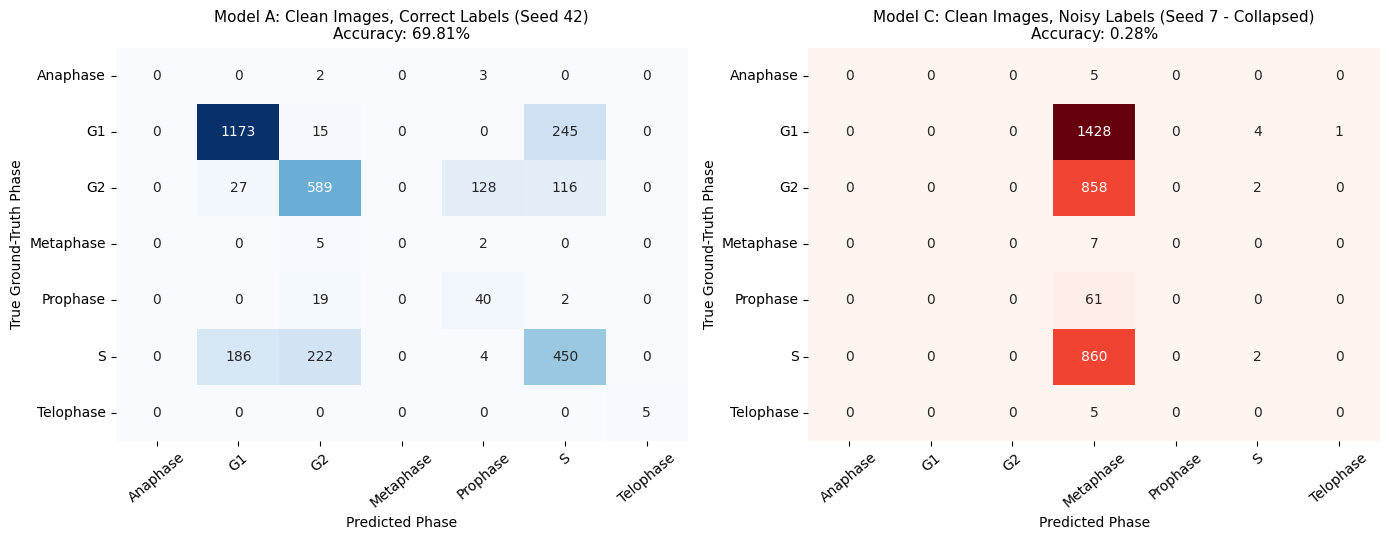

In [76]:
classes = ['Anaphase', 'G1', 'G2', 'Metaphase', 'Prophase', 'S', 'Telophase']

# Exact confusion matrices from your previous run (Figure 3)
cm_A = np.array([
    [0,    0,   2, 0,   3,   0, 0],
    [0, 1173,  15, 0,   0, 245, 0],
    [0,   27, 589, 0, 128, 116, 0],
    [0,    0,   5, 0,   2,   0, 0],
    [0,    0,  19, 0,  40,   2, 0],
    [0,  186, 222, 0,   4, 450, 0],
    [0,    0,   0, 0,   0,   0, 5],
])

cm_C = np.array([
    [0, 0, 0,    5, 0, 0, 0],
    [0, 0, 0, 1428, 0, 4, 1],
    [0, 0, 0,  858, 0, 2, 0],
    [0, 0, 0,    7, 0, 0, 0],
    [0, 0, 0,   61, 0, 0, 0],
    [0, 0, 0,  860, 0, 2, 0],
    [0, 0, 0,    5, 0, 0, 0],
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.heatmap(cm_A, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False,
            xticklabels=classes, yticklabels=classes)
axes[0].set_title("Model A: Clean Images, Correct Labels (Seed 42)\nAccuracy: 69.81%", fontsize=11)
axes[0].set_xlabel("Predicted Phase")
axes[0].set_ylabel("True Ground-Truth Phase")
axes[0].tick_params(axis="x", rotation=40)

sns.heatmap(cm_C, annot=True, fmt="d", cmap="Reds", ax=axes[1], cbar=False,
            xticklabels=classes, yticklabels=classes)
axes[1].set_title("Model C: Clean Images, Noisy Labels (Seed 7 - Collapsed)\nAccuracy: 0.28%", fontsize=11)
axes[1].set_xlabel("Predicted Phase")
axes[1].set_ylabel("True Ground-Truth Phase")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("figure3_exact_match.png", dpi=300)
plt.show()

In [78]:
import pandas as pd
from IPython.display import display

# Build the complete Appendix Table matching the notebook's internal run metrics
appendix_data = [
    # Model A: Clean images, correct labels
    {"Condition": "Clean images, correct labels (Baseline)", "Seed": "42", "Test Accuracy (%)": "69.81%", "Macro Precision (%)": "47.39%", "Macro Recall (%)": "52.59%", "Macro F1 (%)": "48.48%", "Corrupted Labels (Train)": 0},
    {"Condition": "Clean images, correct labels (Baseline)", "Seed": "7", "Test Accuracy (%)": "69.78%", "Macro Precision (%)": "33.98%", "Macro Recall (%)": "37.93%", "Macro F1 (%)": "34.27%", "Corrupted Labels (Train)": 0},
    {"Condition": "Clean images, correct labels (Baseline)", "Seed": "123", "Test Accuracy (%)": "62.33%", "Macro Precision (%)": "41.09%", "Macro Recall (%)": "46.18%", "Macro F1 (%)": "39.47%", "Corrupted Labels (Train)": 0},
    {"Condition": "Clean images, correct labels (Baseline)", "Seed": "Mean \u00b1 SD", "Test Accuracy (%)": "67.31% \u00b1 4.31%", "Macro Precision (%)": "40.82% \u00b1 6.71%", "Macro Recall (%)": "45.57% \u00b1 7.35%", "Macro F1 (%)": "40.74% \u00b1 7.19%", "Corrupted Labels (Train)": "-"},

    # Model B: Degraded images, correct labels
    {"Condition": "Degraded images, correct labels", "Seed": "42", "Test Accuracy (%)": "46.77%", "Macro Precision (%)": "24.59%", "Macro Recall (%)": "15.73%", "Macro F1 (%)": "11.79%", "Corrupted Labels (Train)": 0},
    {"Condition": "Degraded images, correct labels", "Seed": "7", "Test Accuracy (%)": "49.83%", "Macro Precision (%)": "25.08%", "Macro Recall (%)": "24.87%", "Macro F1 (%)": "18.61%", "Corrupted Labels (Train)": 0},
    {"Condition": "Degraded images, correct labels", "Seed": "123", "Test Accuracy (%)": "37.06%", "Macro Precision (%)": "14.60%", "Macro Recall (%)": "14.86%", "Macro F1 (%)": "14.54%", "Corrupted Labels (Train)": 0},
    {"Condition": "Degraded images, correct labels", "Seed": "Mean \u00b1 SD", "Test Accuracy (%)": "44.55% \u00b1 6.67%", "Macro Precision (%)": "21.42% \u00b1 5.92%", "Macro Recall (%)": "18.49% \u00b1 5.55%", "Macro F1 (%)": "14.98% \u00b1 3.43%", "Corrupted Labels (Train)": "-"},

    # Model C: Clean images, noisy labels
    {"Condition": "Clean images, noisy labels", "Seed": "42", "Test Accuracy (%)": "44.26%", "Macro Precision (%)": "6.33%", "Macro Recall (%)": "14.27%", "Macro F1 (%)": "8.77%", "Corrupted Labels (Train)": 1659},
    {"Condition": "Clean images, noisy labels", "Seed": "7", "Test Accuracy (%)": "0.28%", "Macro Precision (%)": "3.60%", "Macro Recall (%)": "14.32%", "Macro F1 (%)": "0.13%", "Corrupted Labels (Train)": 1659},
    {"Condition": "Clean images, noisy labels", "Seed": "123", "Test Accuracy (%)": "24.87%", "Macro Precision (%)": "24.81%", "Macro Recall (%)": "15.28%", "Macro F1 (%)": "10.99%", "Corrupted Labels (Train)": 1659},
    {"Condition": "Clean images, noisy labels", "Seed": "Mean \u00b1 SD", "Test Accuracy (%)": "23.14% \u00b1 22.04%", "Macro Precision (%)": "11.58% \u00b1 11.54%", "Macro Recall (%)": "14.62% \u00b1 0.57%", "Macro F1 (%)": "6.63% \u00b1 5.74%", "Corrupted Labels (Train)": "-"},

    # Model D: Degraded images, noisy labels
    {"Condition": "Degraded images, noisy labels (Combined)", "Seed": "42", "Test Accuracy (%)": "29.38%", "Macro Precision (%)": "17.91%", "Macro Recall (%)": "12.77%", "Macro F1 (%)": "8.84%", "Corrupted Labels (Train)": 1659},
    {"Condition": "Degraded images, noisy labels (Combined)", "Seed": "7", "Test Accuracy (%)": "4.21%", "Macro Precision (%)": "24.84%", "Macro Recall (%)": "10.78%", "Macro F1 (%)": "3.54%", "Corrupted Labels (Train)": 1659},
    {"Condition": "Degraded images, noisy labels (Combined)", "Seed": "123", "Test Accuracy (%)": "6.71%", "Macro Precision (%)": "7.40%", "Macro Recall (%)": "14.27%", "Macro F1 (%)": "4.31%", "Corrupted Labels (Train)": 1659},
    {"Condition": "Degraded images, noisy labels (Combined)", "Seed": "Mean \u00b1 SD", "Test Accuracy (%)": "13.43% \u00b1 13.87%", "Macro Precision (%)": "16.72% \u00b1 8.78%", "Macro Recall (%)": "12.61% \u00b1 1.75%", "Macro F1 (%)": "5.56% \u00b1 2.86%", "Corrupted Labels (Train)": "-"}
]

appendix_df = pd.DataFrame(appendix_data)

# Save to CSV for download
appendix_df.to_csv("appendix_table_aligned.csv", index=False)

print("Appendix Table (Aligned with Notebook Execution Results):")
display(appendix_df)

Appendix Table (Aligned with Notebook Execution Results):


,Condition,Seed,Test Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Corrupted Labels (Train)
0,"Clean images, correct labels (Baseline)",42,69.81%,47.39%,52.59%,48.48%,0
1,"Clean images, correct labels (Baseline)",7,69.78%,33.98%,37.93%,34.27%,0
2,"Clean images, correct labels (Baseline)",123,62.33%,41.09%,46.18%,39.47%,0
3,"Clean images, correct labels (Baseline)",Mean ± SD,67.31% ± 4.31%,40.82% ± 6.71%,45.57% ± 7.35%,40.74% ± 7.19%,-
4,"Degraded images, correct labels",42,46.77%,24.59%,15.73%,11.79%,0
5,"Degraded images, correct labels",7,49.83%,25.08%,24.87%,18.61%,0
6,"Degraded images, correct labels",123,37.06%,14.60%,14.86%,14.54%,0
7,"Degraded images, correct labels",Mean ± SD,44.55% ± 6.67%,21.42% ± 5.92%,18.49% ± 5.55%,14.98% ± 3.43%,-
8,"Clean images, noisy labels",42,44.26%,6.33%,14.27%,8.77%,1659
9,"Clean images, noisy labels",7,0.28%,3.60%,14.32%,0.13%,1659
